# The Bias-Variance Tradeoff: Mathematical Foundation and PyTorch Implementation

**Author**: Machine Learning Fundamentals

This notebook explores the fundamental concept of the **Bias-Variance Tradeoff** in machine learning. We will first delve into its mathematical decomposition and then provide a practical PyTorch implementation to illustrate how different model complexities exhibit varying levels of bias and variance.

---
## 1. Introduction
### What is the Bias-Variance Tradeoff?

The bias-variance tradeoff is a core concept in machine learning that describes the relationship between a model's complexity and its generalization error. Understanding this tradeoff is crucial for building models that perform well on unseen data.

There are three primary sources of prediction error:

1.  **Bias**: This error arises from overly simplistic assumptions in the learning algorithm, causing the model to consistently miss the true relationship between features and target. High bias often leads to **underfitting**.
2.  **Variance**: This error results from the model's excessive sensitivity to the training data. A model with high variance will fit the noise in the training data, leading to poor performance on new, unseen data. High variance often leads to **overfitting**.
3.  **Irreducible Error**: This is the inherent noise in the problem itself that cannot be reduced by any model. It's due to unmeasured variables or inherent randomness in the data generating process.

> **Key Insight**: Bias and variance are inversely related; reducing one typically increases the other. The goal is to find the right balance to minimize the total error.

---
## 2. Mathematical Foundation
### Problem Setup

Consider a scenario where the target variable $y$ is generated from a true function $f(x)$ plus some noise $\epsilon$:

$$ y = f(x) + \epsilon $$

Where:
* $f(x)$ is the true, unknown function.
* $\epsilon$ is the irreducible error (noise), typically assumed to be drawn from a normal distribution with mean 0 and variance $\sigma^2$, i.e., $\epsilon \sim \mathcal{N}(0, \sigma^2)$.
* $\hat{y}(x)$ is our model's prediction for a given input $x$.

Our goal is to minimize the expected prediction error, which is often measured by the **Mean Squared Error (MSE)**:

$$ \text{Expected Error} = \mathbb{E}[(y - \hat{y})^2] $$

### Bias-Variance Decomposition - Step 1

Let's expand the expected squared error:

$$ \mathbb{E}[(y - \hat{y})^2] = \mathbb{E}[(f(x) + \epsilon - \hat{y})^2] $$

Expanding the square $(A+B+C)^2 = A^2+B^2+C^2+2AB+2AC+2BC$ where $A = f(x) - \hat{y}$, $B = \epsilon$:

$$ = \mathbb{E}[(f(x) - \hat{y})^2 + \epsilon^2 + 2(f(x) - \hat{y})\epsilon] $$
Applying linearity of expectation:
$$ = \mathbb{E}[(f(x) - \hat{y})^2] + \mathbb{E}[\epsilon^2] + 2\mathbb{E}[(f(x) - \hat{y})\epsilon] $$

Since $\mathbb{E}[\epsilon] = 0$ (noise has zero mean) and $\epsilon$ is independent of $f(x)$ and $\hat{y}$, the cross term $2\mathbb{E}[(f(x) - \hat{y})\epsilon]$ vanishes:

$$ = \mathbb{E}[(f(x) - \hat{y})^2] + \sigma^2 $$
Where $\mathbb{E}[\epsilon^2] = \text{Var}(\epsilon) + (\mathbb{E}[\epsilon])^2 = \sigma^2 + 0^2 = \sigma^2$.

### Bias-Variance Decomposition - Step 2

Now let's focus on the first term: $\mathbb{E}[(f(x) - \hat{y})^2]$. We can add and subtract $\mathbb{E}[\hat{y}]$ (the expected prediction of our model over different datasets) inside the term:

$$ \mathbb{E}[(f(x) - \hat{y})^2] = \mathbb{E}[(f(x) - \mathbb{E}[\hat{y}] + \mathbb{E}[\hat{y}] - \hat{y})^2] $$

Let $A = (f(x) - \mathbb{E}[\hat{y}])$ and $B = (\mathbb{E}[\hat{y}] - \hat{y})$. Expanding $(A+B)^2 = A^2 + B^2 + 2AB$:

$$ = \mathbb{E}[(f(x) - \mathbb{E}[\hat{y}])^2 + (\mathbb{E}[\hat{y}] - \hat{y})^2 + 2(f(x) - \mathbb{E}[\hat{y}])(\mathbb{E}[\hat{y}] - \hat{y})] $$

Applying linearity of expectation again:

$$ = \mathbb{E}[(f(x) - \mathbb{E}[\hat{y}])^2] + \mathbb{E}[(\mathbb{E}[\hat{y}] - \hat{y})^2] + 2\mathbb{E}[(f(x) - \mathbb{E}[\hat{y}])(\mathbb{E}[\hat{y}] - \hat{y})] $$

The cross term $2\mathbb{E}[(f(x) - \mathbb{E}[\hat{y}])(\mathbb{E}[\hat{y}] - \hat{y})]$ is zero because $f(x)$ and $\mathbb{E}[\hat{y}]$ are constants with respect to the expectation over datasets (which $\hat{y}$ varies by). Also, $\mathbb{E}[\mathbb{E}[\hat{y}] - \hat{y}] = \mathbb{E}[\mathbb{E}[\hat{y}]] - \mathbb{E}[\hat{y}] = \mathbb{E}[\hat{y}] - \mathbb{E}[\hat{y}] = 0$.

So, we are left with:

$$ = (f(x) - \mathbb{E}[\hat{y}])^2 + \mathbb{E}[(\mathbb{E}[\hat{y}] - \hat{y})^2] $$

### Final Decomposition

Combining the results from Step 1 and Step 2, we get the fundamental Bias-Variance Decomposition:

$$ \mathbb{E}[(y - \hat{y})^2] = \underbrace{(f(x) - \mathbb{E}[\hat{y}])^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}[(\mathbb{E}[\hat{y}] - \hat{y})^2]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Noise}} $$

Let's break down each term:

* **Bias$^2$**: This is the squared difference between the true function $f(x)$ and the expected prediction of our model $\mathbb{E}[\hat{y}]$. High bias indicates that the model's average prediction is far from the true value.
* **Variance**: This is the expected squared deviation of predictions from their mean expected prediction. High variance indicates that the model's predictions fluctuate significantly depending on the specific training data it receives.
* **Noise ($\sigma^2$)**: This is the irreducible error, representing the inherent randomness or noise in the data itself. It's a lower bound on the error any model can achieve.

---
## 3. The Tradeoff
### Understanding the Tradeoff

The core of the bias-variance tradeoff lies in how model complexity affects these two error components:

| Model Type        | Bias     | Variance | Characteristics             | Example                         |
| :---------------- | :------- | :------- | :-------------------------- | :------------------------------ |
| **Simple models** | High     | Low      | Consistent but inaccurate, **underfitting** | Linear regression on nonlinear data |
| **Complex models**| Low      | High     | Accurate but inconsistent, **overfitting** | Deep neural network, decision tree with no depth limit |

The total expected error is the sum of these components:

$$ \text{Error} = \text{Bias}^2 + \text{Variance} + \text{Noise} $$

The goal is to find the optimal model complexity that minimizes the sum of $\text{Bias}^2 + \text{Variance}$. This sweet spot often lies between very simple and very complex models.

---
## 4. PyTorch Implementation
### PyTorch Setup

First, let's import the necessary libraries and configure our device (CPU or GPU) and set random seeds for reproducibility.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility across numpy and torch
torch.manual_seed(42)
np.random.seed(42)

# Device configuration: Use CUDA (GPU) if available, otherwise fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Data Generation

We'll create a synthetic dataset where we know the true underlying function. This allows us to calculate the bias and variance accurately against this true function. The data generation function will add Gaussian noise to simulate real-world data.

The true function used here is $f(x) = x^2 + 0.5 * \sin(4 * \pi * x)$.

In [ ]:
def generate_data(n_samples=100, noise_std=0.3):
    """Generate synthetic data with known true function and added noise"""
    # Generate X values uniformly between -1 and 1
    X = np.random.uniform(-1, 1, n_samples)
    # True function: f(x) = x^2 + 0.5*sin(4*pi*x)
    y_true = X**2 + 0.5 * np.sin(4 * np.pi * X)
    # Add Gaussian noise to the true function output
    y = y_true + np.random.normal(0, noise_std, n_samples)
    return X.reshape(-1, 1), y, y_true

# Generate a fixed, dense test set for evaluating model predictions and true function
X_test = np.linspace(-1, 1, 200).reshape(-1, 1)
y_test_true = X_test.flatten()**2 + 0.5 * np.sin(4 * np.pi * X_test.flatten())

# Convert test data to PyTorch tensors and move to the selected device (CPU/GPU)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_true_tensor = torch.FloatTensor(y_test_true).to(device)

### Neural Network Models

We define a simple feedforward neural network class. We'll then create different configurations of this network, representing varying levels of complexity, by changing the number and size of hidden layers. These configurations will represent models with high bias (simple), balanced, and high variance (complex).

In [ ]:
class SimpleNN(nn.Module):
    """Simple neural network with configurable complexity using hidden_sizes list"""
    def __init__(self, input_size, hidden_sizes, output_size=1):
        super(SimpleNN, self).__init__()
        layers = []
        prev_size = input_size

        # Dynamically build layers based on hidden_sizes list
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU()) # Using ReLU activation function
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Define model configurations based on their hidden layer architectures.
# These represent different levels of model complexity.
model_configs = {
    'simple': [5],          # High bias, low variance (few parameters, underfits)
    'medium': [20, 10],     # Balanced bias-variance (moderate complexity)
    'complex': [50, 30, 20] # Low bias, high variance (many parameters, overfits)
}

### Training and Prediction Functions

These helper functions will encapsulate the training loop for our neural networks and the process of getting predictions from a trained model.

In [ ]:
def train_model(X, y, model, epochs=1000, lr=0.01):
    """Train a neural network model using MSE loss and Adam optimizer"""
    criterion = nn.MSELoss() # Mean Squared Error Loss is suitable for regression
    optimizer = optim.Adam(model.parameters(), lr=lr) # Adam optimizer for efficient training

    # Convert numpy arrays to PyTorch tensors and move them to the selected device
    X_tensor = torch.FloatTensor(X).to(device)
    y_tensor = torch.FloatTensor(y).to(device)

    model.train() # Set the model to training mode (e.g., enables dropout if used)
    for epoch in range(epochs):
        optimizer.zero_grad() # Clear gradients from previous iteration
        outputs = model(X_tensor) # Perform a forward pass
        # Squeeze outputs to match target tensor shape (e.g., from [N, 1] to [N])
        loss = criterion(outputs.squeeze(), y_tensor) # Calculate the loss
        loss.backward() # Perform a backward pass to compute gradients
        optimizer.step() # Update model weights using the optimizer

    return model

def get_predictions(model, X):
    """Get model predictions for a given input X"""
    model.eval() # Set the model to evaluation mode (e.g., disables dropout)
    with torch.no_grad(): # Disable gradient calculations for inference, saves memory and computation
        X_tensor = torch.FloatTensor(X).to(device)
        predictions = model(X_tensor)
    # Move predictions back to CPU and convert to a flat numpy array
    return predictions.cpu().numpy().flatten()

### Bias-Variance Calculation Function

To calculate bias and variance, we need to train multiple instances of the same model on different random samples of the training data. This allows us to observe the variability (variance) in predictions and the average deviation from the true function (bias).

For each experiment:
1.  Generate a new training dataset (simulating different random samples).
2.  Create and train a new instance of the model.
3.  Get predictions on a fixed, independent test set (`X_test`).

After many experiments, we can calculate:
* **Mean Predictions**: The average of all predictions for each test point across different model instances.
* **Bias Squared**: The squared difference between the true function ($f(x)$) and the mean predictions, averaged over all test points.
* **Variance**: The variance of the predictions across experiments for each test point, averaged over all test points. This measures how much the predictions vary from one training run to another.

In [ ]:
def calculate_bias_variance(model_name, hidden_sizes, n_experiments=50):
    """Calculates bias squared, variance, mean predictions, and all predictions
    for a given model configuration over multiple experiments."""
    predictions = [] # List to store predictions from each experiment

    # Run multiple experiments to estimate bias and variance robustly
    for i in range(n_experiments):
        # Generate a new random training dataset for each experiment
        # This is crucial for observing variance as models are trained on different data subsets
        X_train, y_train, _ = generate_data(n_samples=100)

        # Create a fresh model instance for each experiment to ensure independence
        model = SimpleNN(input_size=1, hidden_sizes=hidden_sizes).to(device)
        model = train_model(X_train, y_train, model) # Train the model

        # Get predictions on the fixed test set (X_test) using the newly trained model
        preds = get_predictions(model, X_test)
        predictions.append(preds)

    # Convert list of predictions to a numpy array for easier calculations
    predictions = np.array(predictions) # Shape: (n_experiments, n_test_points)

    # Calculate mean predictions across all experiments for each test point
    mean_predictions = np.mean(predictions, axis=0)

    # Calculate Bias^2: (True_Function - Mean_Prediction)^2 averaged over test points
    # This measures how far the average prediction is from the true function
    bias_squared = np.mean((y_test_true - mean_predictions)**2)

    # Calculate Variance: Variance of predictions for each test point, averaged over test points
    # This measures how much individual predictions vary around their mean prediction
    variance = np.mean(np.var(predictions, axis=0)) # np.var calculates variance along a given axis

    return bias_squared, variance, mean_predictions, predictions

### Running the Experiment

Now, we'll iterate through our defined model configurations, calculate their bias and variance, and store the results. We use `n_experiments=50` to get a good estimate of the average behavior.

In [ ]:
# Dictionary to store results for each model complexity
results = {}

# Loop through each model configuration (simple, medium, complex) and run the experiment
for model_name, hidden_sizes in model_configs.items():
    print(f"Calculating bias-variance for {model_name.capitalize()} model...")

    # Call the function to compute bias, variance, and predictions over multiple runs
    bias_sq, variance, mean_preds, all_preds = calculate_bias_variance(
        model_name, hidden_sizes, n_experiments=50 # Using 50 experiments for stable estimates
    )

    # Store the calculated metrics and prediction data in the results dictionary
    results[model_name] = {
        'bias_squared': bias_sq,
        'variance': variance,
        'total_error': bias_sq + variance, # Sum of bias squared and variance
        'mean_predictions': mean_preds,
        'all_predictions': all_preds
    }

    # Print the calculated values for each model for quick review
    print(f"  Bias²: {bias_sq:.4f}")
    print(f"  Variance: {variance:.4f}")
    print(f"  Total Error (Bias² + Variance): {bias_sq + variance:.4f}")
    print()

Calculating bias-variance for Simple model...
  Bias²: 0.1090
  Variance: 0.0289
  Total Error (Bias² + Variance): 0.1379

Calculating bias-variance for Medium model...
  Bias²: 0.0343
  Variance: 0.0419
  Total Error (Bias² + Variance): 0.0762

Calculating bias-variance for Complex model...
  Bias²: 0.0013
  Variance: 0.0286
  Total Error (Bias² + Variance): 0.0299



### Results Visualization

Let's visualize the results to clearly see the bias-variance tradeoff. We'll create a 2x2 grid of plots:

1.  **Bias-Variance Tradeoff Bar Chart**: Shows the calculated bias squared, variance, and total error for each model complexity.
2.  **Model Mean Predictions vs True Function**: Compares the average prediction of each model with the true underlying function.
3.  **Complex Model: Individual Predictions Showing High Variance**: Illustrates how individual predictions from the complex model vary significantly.
4.  **Simple Model: Individual Predictions Showing Low Variance**: Demonstrates the consistency (low variance) of the simple model's predictions.

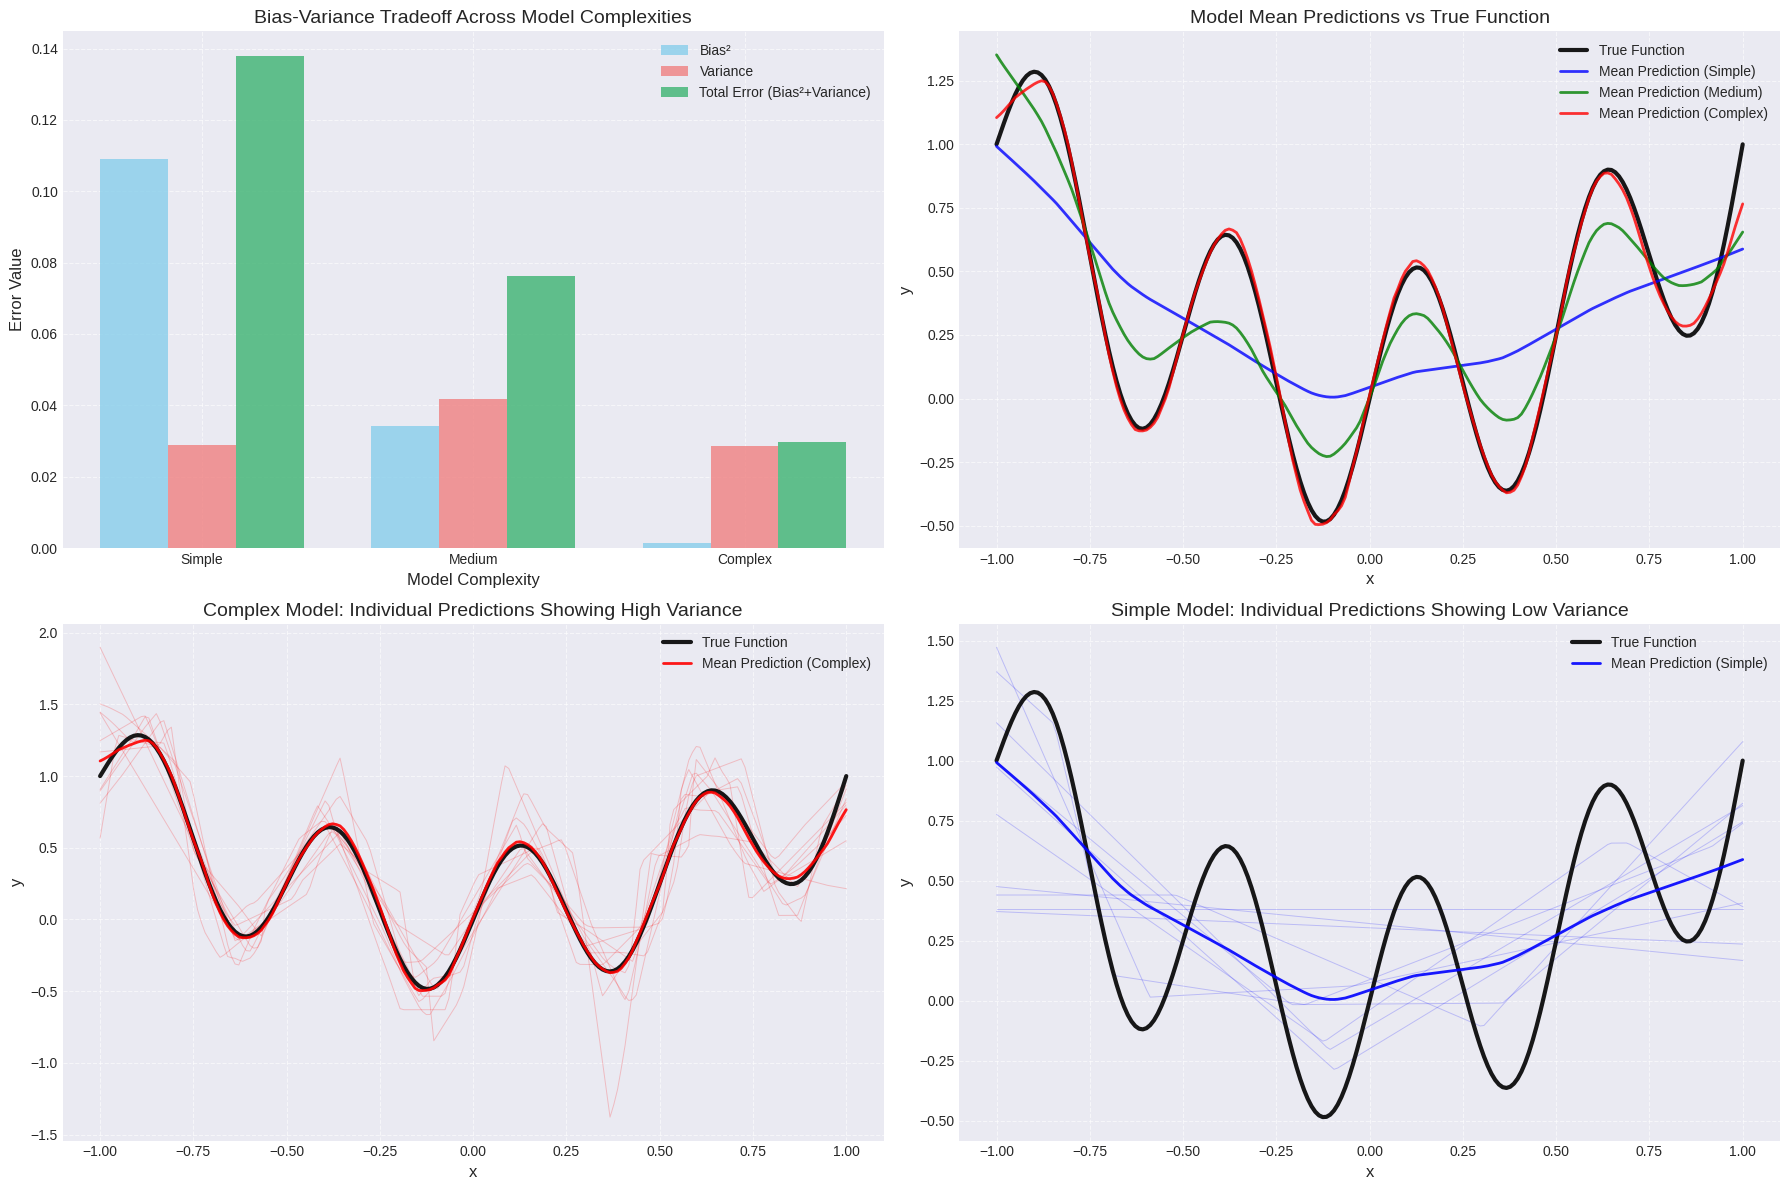

In [ ]:
# Configure plot style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 12)) # Create a 2x2 grid of subplots

# --- Plot 1: Bias-Variance Tradeoff Bar Chart ---
model_names = list(results.keys())
biases = [results[name]['bias_squared'] for name in model_names]
variances = [results[name]['variance'] for name in model_names]
total_errors = [results[name]['total_error'] for name in model_names]

x = np.arange(len(model_names)) # X-axis positions for the bars
width = 0.25 # Width of each bar

axes[0, 0].bar(x - width, biases, width, label='Bias²', alpha=0.8, color='skyblue')
axes[0, 0].bar(x, variances, width, label='Variance', alpha=0.8, color='lightcoral')
axes[0, 0].bar(x + width, total_errors, width, label='Total Error (Bias²+Variance)', alpha=0.8, color='mediumseagreen')
axes[0, 0].set_xlabel('Model Complexity', fontsize=12)
axes[0, 0].set_ylabel('Error Value', fontsize=12)
axes[0, 0].set_title('Bias-Variance Tradeoff Across Model Complexities', fontsize=14)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels([name.capitalize() for name in model_names], fontsize=10)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: True function vs Mean Predictions for each model ---
axes[0, 1].plot(X_test.flatten(), y_test_true, 'k-',
                 linewidth=3, label='True Function', alpha=0.9) # True function in black
colors = ['blue', 'green', 'red'] # Colors for simple, medium, complex models' mean predictions

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    axes[0, 1].plot(X_test.flatten(),
                     results[model_name]['mean_predictions'],
                     color=color, linewidth=2,
                     label=f'Mean Prediction ({model_name.capitalize()})', alpha=0.8)

axes[0, 1].set_xlabel('x', fontsize=12)
axes[0, 1].set_ylabel('y', fontsize=12)
axes[0, 1].set_title('Model Mean Predictions vs True Function', fontsize=14)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# --- Plot 3: Visualization of high variance for the complex model ---
# Show a subset of individual predictions from the complex model to illustrate variance
sample_indices = np.random.choice(results['complex']['all_predictions'].shape[0], 10, replace=False)
for idx in sample_indices:
    axes[1, 0].plot(X_test.flatten(),
                     results['complex']['all_predictions'][idx],
                     'r-', alpha=0.2, linewidth=0.7) # Faint red lines for individual predictions

axes[1, 0].plot(X_test.flatten(), y_test_true, 'k-',
                 linewidth=3, label='True Function', alpha=0.9)
axes[1, 0].plot(X_test.flatten(),
                 results['complex']['mean_predictions'],
                 'red', linewidth=2, label='Mean Prediction (Complex)', alpha=0.9)
axes[1, 0].set_xlabel('x', fontsize=12)
axes[1, 0].set_ylabel('y', fontsize=12)
axes[1, 0].set_title('Complex Model: Individual Predictions Showing High Variance', fontsize=14)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# --- Plot 4: Visualization of low variance for the simple model ---
# Show a subset of individual predictions from the simple model to illustrate its low variance
sample_indices = np.random.choice(results['simple']['all_predictions'].shape[0], 10, replace=False)
for idx in sample_indices:
    axes[1, 1].plot(X_test.flatten(),
                     results['simple']['all_predictions'][idx],
                     'b-', alpha=0.2, linewidth=0.7) # Faint blue lines for individual predictions

axes[1, 1].plot(X_test.flatten(), y_test_true, 'k-',
                 linewidth=3, label='True Function', alpha=0.9)
axes[1, 1].plot(X_test.flatten(),
                 results['simple']['mean_predictions'],
                 'blue', linewidth=2, label='Mean Prediction (Simple)', alpha=0.9)
axes[1, 1].set_xlabel('x', fontsize=12)
axes[1, 1].set_ylabel('y', fontsize=12)
axes[1, 1].set_title('Simple Model: Individual Predictions Showing Low Variance', fontsize=14)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the plots

---
## 5. Key Insights
### Experimental Results

From the experiment, we typically observe the following trends:

* **Simple Model (High Bias, Low Variance)**:
    * The mean prediction curve (blue line) significantly deviates from the true function (black line), indicating **high bias**. This means the model is consistently wrong on average.
    * The individual predictions cluster closely together (faint blue lines), showing **low variance**. This means the model is consistent in its wrong predictions, regardless of the specific training data.
    * This model **underfits** the data; it's too simple to capture the underlying patterns.

* **Medium Model (Balanced)**:
    * The mean prediction curve (green line) closely approximates the true function, indicating **low bias**.
    * The individual predictions are more spread out than the simple model but less than the complex model, indicating a **moderate variance**.
    * This model often achieves the lowest total error because it effectively balances bias and variance.

* **Complex Model (Low Bias, High Variance)**:
    * The mean prediction curve (red line) is very close to the true function, suggesting **low bias**. The model is capable of learning the underlying pattern.
    * However, the individual prediction curves (faint red lines) show significant fluctuations and spread, indicating **high variance**. This means the model's predictions are highly sensitive to the specific training data, including its noise.
    * This model **overfits** the training data; it's too sensitive to the specific noise in each training set.

These observations confirm the theoretical bias-variance tradeoff: as model complexity increases, bias tends to decrease while variance tends to increase. The optimal model is found at the sweet spot where their sum is minimized.

### Practical Implications

Understanding the bias-variance tradeoff is vital for practical machine learning:

* **Model Selection**: Choose a model complexity that minimizes the total error on unseen data, often identified through validation techniques.
* **Regularization**: Techniques like L1/L2 regularization, dropout, and early stopping help reduce **variance** (prevent overfitting) without drastically increasing bias.
* **Ensemble Methods**: Methods like Bagging (e.g., Random Forests) primarily reduce **variance** by averaging predictions from multiple models, while Boosting (e.g., Gradient Boosting) primarily reduces **bias**.
* **Cross-Validation**: Use cross-validation (e.g., k-fold cross-validation) to estimate a model's generalization error and find the optimal complexity.
* **Data Size**: Increasing the amount of training data generally helps reduce **variance**, as the model has more examples to learn the true underlying pattern rather than noise.

> **Key Takeaway**: The ultimate goal is to find a model that balances bias and variance to minimize generalization error, not just to achieve a low training error.

---
## 6. Conclusion

The bias-variance tradeoff is a cornerstone concept in machine learning, offering a rigorous framework for understanding model performance. Through mathematical decomposition and practical PyTorch implementation, we've seen how model complexity directly impacts the balance between bias and variance.

The optimal complexity for a model depends on several factors, including:
* The inherent complexity of the problem.
* The amount and quality of available training data.
* The level of noise in the data.
* Computational constraints.

By carefully considering and managing this tradeoff, we can develop more robust and effective machine learning models that generalize well to new data.